In [18]:
import pandas as pd
import xarray as xr
import salem
import numpy as np

In [10]:
filein = "/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_01:00:00"

wrf_ds = salem.open_xr_dataset("/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_01:00:00")

In [8]:
wrf_ds

<xarray.Dataset>
Dimensions:       (Time: 1, south_north: 702, west_east: 558)
Coordinates:
    XLAT          (Time, south_north, west_east) float32 ...
    XLONG         (Time, south_north, west_east) float32 ...
  * west_east     (west_east) float64 -3.082e+06 -3.079e+06 ... -1.411e+06
  * south_north   (south_north) float64 -4.124e+06 -4.121e+06 ... -2.021e+06
Dimensions without coordinates: Time
Data variables: (12/60)
    Times         (Time) |S19 ...
    Q2            (Time, south_north, west_east) float32 ...
    T2            (Time, south_north, west_east) float32 ...
    PSFC          (Time, south_north, west_east) float32 ...
    U10           (Time, south_north, west_east) float32 ...
    V10           (Time, south_north, west_east) float32 ...
    ...            ...
    PBLH          (Time, south_north, west_east) float32 ...
    HFX           (Time, south_north, west_east) float32 ...
    QFX           (Time, south_north, west_east) float32 ...
    LH            (Time, south_north, west_east) float32 ...
    SNOWC         (Time, south_north, west_east) float32 ...
    TKESFCF       (Time, south_north, west_east) float32 ...
Attributes: (12/87)
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      2023-04-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    SOUTH-NORTH_GRID_DIMENSION:      703
    BOTTOM-TOP_GRID_DIMENSION:       51
    DX:                              3000.0
    ...                              ...
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    pyproj_srs:                      +proj=stere +lat_0=90 +lat_ts=60 +lon_0=...

In [9]:
print(list(wrf_ds.variables))

['Times', 'XLAT', 'XLONG', 'Q2', 'T2', 'PSFC', 'U10', 'V10', 'GRDFLX', 'SNOW', 'SNOWH', 'Z0', 'HGT', 'RAINC', 'RAINSH', 'RAINNC', 'I_RAINC', 'I_RAINNC', 'SNOWNC', 'GRAUPELNC', 'HAILNC', 'SWDOWN', 'SWDOWNC', 'DIFFUSE_FRAC', 'SWDDIR', 'SWDDIRC', 'SWDDNI', 'SWDDNIC', 'SWDDIF', 'ACSWUPB', 'ACSWUPBC', 'ACSWDNB', 'ACSWDNBC', 'ACLWUPB', 'ACLWUPBC', 'ACLWDNB', 'ACLWDNBC', 'I_ACSWUPB', 'I_ACSWUPBC', 'I_ACSWDNB', 'I_ACSWDNBC', 'I_ACLWUPB', 'I_ACLWUPBC', 'I_ACLWDNB', 'I_ACLWDNBC', 'SWDNT', 'SWDNTC', 'SWDNB', 'SWDNBC', 'LWDNT', 'LWDNTC', 'LWDNB', 'LWDNBC', 'ZNT', 'UST', 'RMOL', 'PBLH', 'HFX', 'QFX', 'LH', 'SNOWC', 'TKESFCF', 'west_east', 'south_north']


In [97]:
import xarray as xr

def transform_climatex(ds):

    print(ds.Times)

    fwf_ds = xr.Dataset()

    # Rename variables and change units
    fwf_ds["T"] = ds["T2"] - 273.15
    fwf_ds["U10"] = ds["U10"]
    fwf_ds["V10"] = ds["V10"]

    fwf_ds["SNOWH"] = ds["SNOWH"]
    fwf_ds["SNOWC"] = ds["SNOWC"]
    fwf_ds["SNW"] = ds["SNOW"]

    # Calculate precipitation
    precip = (
    ds.RAINC +
    ds.RAINNC +
    ds.RAINSH
    )

    # WRF precipitation variables (RAINC, RAINNC, RAINSH) are cumulative from model initialization.
    # Remove the initial accumulated value to match the operational FWF input convention.
    fwf_ds["r_o"] = precip - precip.isel(Time=0)

    

    # Calculate wind speed and direction
    fwf_ds["W"] = np.sqrt(
    fwf_ds.U10**2 + fwf_ds.V10**2
    )

    fwf_ds["WD"] = (
        270 - np.rad2deg(
            np.arctan2(fwf_ds.V10, fwf_ds.U10)
        )
    ) % 360

    # Calculate dewpoint from Q2
    q = ds.Q2
    p = ds.PSFC / 100

    e = (q*p)/(0.622 + 0.378*q)

    ln_ratio = np.log(e/6.112)

    fwf_ds["TD"] = (
        237.3 * ln_ratio /
        (17.27 - ln_ratio)
    )

    # Calculate relative humidity from T and TD
    T = fwf_ds.T
    TD = fwf_ds.TD

    RH = (
        6.11 * 10**(7.5*TD/(237.7+TD))
    ) / (
        6.11 * 10**(7.5*T/(237.7+T))
    ) * 100

    fwf_ds["H"] = xr.where(RH > 100, 100, RH)

    # Add WRF coordinates
    fwf_ds = fwf_ds.assign_coords(
    XLAT=(("south_north", "west_east"), ds.XLAT.isel(Time=0).values),
    XLONG=(("south_north", "west_east"), ds.XLONG.isel(Time=0).values)
    )


    time = pd.to_datetime(
    ds.Times.values.astype(str),
    format="%Y-%m-%d_%H:%M:%S"
    )

    fwf_ds = fwf_ds.assign_coords(
        Time=("Time", time)
    )

    return fwf_ds

In [93]:
fwf_ds = transform_climatex(ds)

<xarray.DataArray 'Times' (Time: 720)>
dask.array<concatenate, shape=(720,), dtype=|S19, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) datetime64[ns] 2023-04-01T01:00:00 ... 2023-05-01


In [94]:
print(fwf_ds)

<xarray.Dataset>
Dimensions:  (Time: 720, south_north: 702, west_east: 558)
Coordinates:
  * Time     (Time) datetime64[ns] 2023-04-01T01:00:00 ... 2023-05-01
    XLAT     (south_north, west_east) float32 43.16 43.18 43.19 ... 66.56 66.57
    XLONG    (south_north, west_east) float32 -126.8 -126.7 ... -125.0 -124.9
Dimensions without coordinates: south_north, west_east
Data variables:
    T        (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    U10      (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    V10      (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    SNOWH    (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    SNOWC    (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    SNW      (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558),

In [61]:
print(fwf_ds.r_o.shape)


(1, 702, 558)


AttributeError: 'Dataset' object has no attribute 'Times'

In [95]:
print(fwf_ds.r_o.isel(Time=slice(0,5)).mean(dim=["south_north","west_east"]).compute())

<xarray.DataArray 'r_o' (Time: 5)>
array([       nan, 0.22841144, 0.23055236, 0.2320041 , 0.2312102 ],
      dtype=float32)
Coordinates:
  * Time     (Time) datetime64[ns] 2023-04-01T01:00:00 ... 2023-04-01T05:00:00


In [96]:
print(fwf_ds.r_o.isel(Time=[0,1,2]).mean(dim=["south_north","west_east"]).compute())

<xarray.DataArray 'r_o' (Time: 3)>
array([       nan, 0.22841144, 0.23055236], dtype=float32)
Coordinates:
  * Time     (Time) datetime64[ns] 2023-04-01T01:00:00 ... 2023-04-01T03:00:00


In [73]:
print(fwf_ds.r_o.values.min())
print(fwf_ds.r_o.values.max())

-4.5701523e-09
106.89815


In [76]:
test = xr.open_dataset(filein)
print(test.Time.shape)

(1,)


In [79]:
import glob

files = glob.glob("/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/*")
print(len(files))
print(files[:5])

720
['/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_01:00:00', '/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_02:00:00', '/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_03:00:00', '/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_04:00:00', '/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/wrfuvic_d03_2023-04-01_05:00:00']


In [80]:
import xarray as xr
import glob

files = sorted(glob.glob("/Volumes/RS_backup/D03/metgrid_2023_04/WRFUVIC/*"))

ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="Time"
)

print(ds)

<xarray.Dataset>
Dimensions:       (Time: 720, south_north: 702, west_east: 558)
Coordinates:
    XLAT          (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    XLONG         (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east
Data variables: (12/60)
    Times         (Time) |S19 dask.array<chunksize=(1,), meta=np.ndarray>
    Q2            (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    T2            (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    PSFC          (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    U10           (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 558), meta=np.ndarray>
    V10           (Time, south_north, west_east) float32 dask.array<chunksize=(1, 702, 

In [81]:
time = pd.to_datetime(
    ds.Times.values.astype(str),
    format="%Y-%m-%d_%H:%M:%S"
)

ds = ds.assign_coords(
    Time=("Time", time)
)

print(ds.Time)

<xarray.DataArray 'Time' (Time: 720)>
array(['2023-04-01T01:00:00.000000000', '2023-04-01T02:00:00.000000000',
       '2023-04-01T03:00:00.000000000', ..., '2023-04-30T22:00:00.000000000',
       '2023-04-30T23:00:00.000000000', '2023-05-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * Time     (Time) datetime64[ns] 2023-04-01T01:00:00 ... 2023-05-01


In [69]:
print(fwf_ds.T.shape)
#print(timezone.Zone.shape)
print(fwf_ds.r_o.shape)
print(fwf_ds.Time.values)

(1, 702, 558)
(1, 702, 558)
['2023-04-01T01:00:00.000000000']


In [31]:
print(fwf_ds)

<xarray.Dataset>
Dimensions:  (south_north: 702, west_east: 558, Time: 1)
Coordinates:
    XLAT     (south_north, west_east) float32 43.16 43.18 43.19 ... 66.56 66.57
    XLONG    (south_north, west_east) float32 -126.8 -126.7 ... -125.0 -124.9
Dimensions without coordinates: south_north, west_east, Time
Data variables:
    T        (Time, south_north, west_east) float32 8.551 8.531 ... -17.01
    U10      (Time, south_north, west_east) float32 11.72 11.76 ... -5.851 -5.98
    V10      (Time, south_north, west_east) float32 5.373 5.542 ... 6.767 6.856
    SNOWH    (Time, south_north, west_east) float32 ...
    SNOWC    (Time, south_north, west_east) float32 ...
    SNW      (Time, south_north, west_east) float32 ...
    r_o      (Time, south_north, west_east) float32 0.0004928 ... 0.001903
    W        (Time, south_north, west_east) float32 12.89 13.0 ... 8.946 9.098
    WD       (Time, south_north, west_east) float32 245.4 244.8 ... 139.1 138.9
    TD       (Time, south_north, west_ea

In [27]:
fwf_ds.T.min(), fwf_ds.T.max()

(<xarray.DataArray 'T' ()>
 array(-22.517471, dtype=float32),
 <xarray.DataArray 'T' ()>
 array(13.465179, dtype=float32))

In [35]:
print(fwf_ds.r_o.max())
print(fwf_ds.r_o.max())
print(fwf_ds.r_o.max())

<xarray.DataArray 'r_o' ()>
array(106.89815, dtype=float32)
<xarray.DataArray 'r_o' ()>
array(106.89815, dtype=float32)
<xarray.DataArray 'r_o' ()>
array(106.89815, dtype=float32)


In [42]:
timezone = xr.open_zarr("../data/timezone/tzone_wrf4_d03-ST.zarr")
timezone = timezone.expand_dims(Time=fwf_ds.Time)

In [43]:
timezone

<xarray.Dataset>
Dimensions:      (Time: 1, south_north: 702, west_east: 558)
Coordinates:
  * Time         (Time) int64 0
    XLAT         (south_north, west_east) float32 dask.array<chunksize=(351, 279), meta=np.ndarray>
    XLONG        (south_north, west_east) float32 dask.array<chunksize=(351, 279), meta=np.ndarray>
  * south_north  (south_north) float64 -4.124e+06 -4.121e+06 ... -2.021e+06
  * west_east    (west_east) float64 -3.082e+06 -3.079e+06 ... -1.411e+06
Data variables:
    Zone         (Time, south_north, west_east) int64 dask.array<chunksize=(1, 176, 279), meta=np.ndarray>
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  Time Zone Offsets From UTC
    pyproj_srs:   +proj=stere +lat_0=90 +lat_ts=60 +lon_0=-90 +x_0=0 +y_0=0 +...
    stagger:      
    units:        hours_

In [44]:
print(fwf_ds.T.shape)
print(timezone.Zone.shape)

(1, 702, 558)
(1, 702, 558)


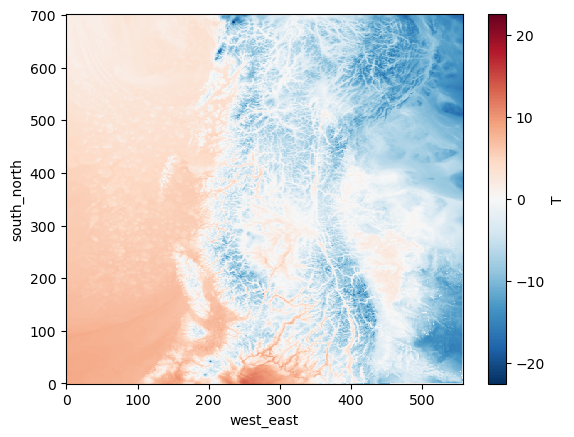

In [45]:
fwf_ds.T.plot()

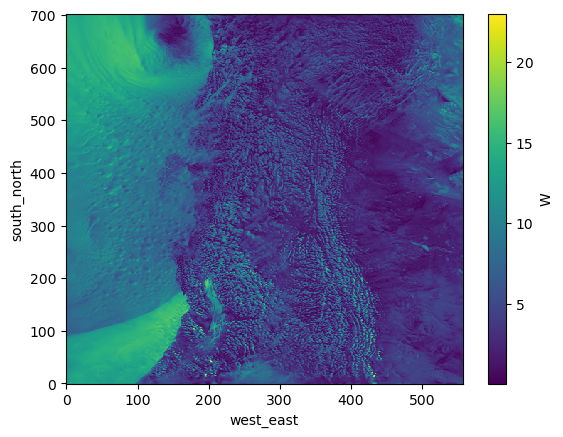

In [54]:
fwf_ds.W.squeeze().plot()

In [51]:
fwf_ds.W.max()

<xarray.DataArray 'W' ()>
array(22.989325, dtype=float32)

In [52]:
fwf_ds.H.min(), fwf_ds.H.max()

(<xarray.DataArray 'H' ()>
 array(29.942986, dtype=float32),
 <xarray.DataArray 'H' ()>
 array(100., dtype=float32))

In [53]:
fwf_ds.r_o.min(), fwf_ds.r_o.max()

(<xarray.DataArray 'r_o' ()>
 array(-4.5701523e-09, dtype=float32),
 <xarray.DataArray 'r_o' ()>
 array(106.89815, dtype=float32))

In [55]:
print(fwf_ds.dims)
print(fwf_ds.coords)

Frozen({'south_north': 702, 'west_east': 558, 'Time': 1})
Coordinates:
    XLAT     (south_north, west_east) float32 43.16 43.18 43.19 ... 66.56 66.57
    XLONG    (south_north, west_east) float32 -126.8 -126.7 ... -125.0 -124.9


In [56]:
print(fwf_ds.Time)

<xarray.DataArray 'Time' (Time: 1)>
array([0])
Dimensions without coordinates: Time


In [70]:
print(fwf_ds.dims)
print(timezone.dims)

Frozen({'Time': 1, 'south_north': 702, 'west_east': 558})
Frozen({'Time': 1, 'south_north': 702, 'west_east': 558})
